# using beamline optimization (blop) with raytracing (Shadow)
awojdyla@lbl.gov, April 2025

This script is based on blop 0.71 (it doesn't work on blop 0.70, but the initial notebook `20240606_xc_bloptools.ipynb` does.) 

use `base 3.10.9` on bl531 feather

I had to fix a few issues which are delineated here.

We used ADURL to readout the images live, by pushing images on the data server. Not very clean, but it worked. Ideally we would have a blop object we could interrogate over the network. blop is also missing compatibility with `async`.

Let's use ``blop`` 

In [1]:
from blop.utils import prepare_re_env

%run -i $prepare_re_env.__file__ --db-type=temp
# it would be great to have a proper bluesky database

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# !pip install shadow3
# that didn't work on the `blop` environment , but it did on the `base`

In [3]:
%matplotlib inline

import Shadow
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

In [11]:
import time
import pathlib
# the toroid() function can calculate the corresponding beam size for a given (x_rot, y_rot) pair. Shadow is used for beamline simulation.
def toroid(X_ROT,Y_ROT):
    beam = Shadow.Beam()
    oe0 = Shadow.Source()
    oe1 = Shadow.OE()
    oe2 = Shadow.OE()

    oe1.X_ROT = X_ROT
    oe1.Y_ROT = Y_ROT

    

    oe0.FDISTR = 3
    oe0.F_PHOT = 0
    oe0.HDIV1 = 0.0
    oe0.HDIV2 = 0.0
    oe0.IDO_VX = 0
    oe0.IDO_VZ = 0
    oe0.IDO_X_S = 0
    oe0.IDO_Y_S = 0
    oe0.IDO_Z_S = 0
    oe0.ISTAR1 = 5676561
    oe0.PH1 = 12000
    oe0.NPOINT = 100000
    oe0.SIGDIX = 5e-05
    oe0.SIGDIZ = 5e-05
    oe0.SIGMAX = 1e-05
    oe0.SIGMAZ = 1e-05
    oe0.VDIV1 = 0.0
    oe0.VDIV2 = 0.0
    oe1.DUMMY = 100.0
    oe1.FMIRR = 3
    oe1.FWRITE = 1
    oe1.F_EXT = 1
    oe1.F_MOVE = 1
    oe1.R_MAJ = 305.3065
    oe1.R_MIN = 0.655
    oe1.T_IMAGE = 0.0

    oe2.ALPHA = 90.0
    oe2.DUMMY = 100.0
    oe2.FCYL = 1
    oe2.FMIRR = 2
    oe2.FWRITE = 1
    oe2.F_DEFAULT = 0
    oe2.SIMAG = 5.0
    oe2.SSOUR = 1000000.0
    oe2.THETA = 88.0
    oe2.T_IMAGE = 5.0
    oe2.T_SOURCE = 5.0

    beam.genSource(oe0)

    beam.traceOE(oe1,1)

    beam.traceOE(oe2,2)

    x_fhwm_m = beam.histo1(1)['fwhm']
    y_fwhm_m = beam.histo1(3)['fwhm']

    a=x_fhwm_m*1e6
    b=y_fwhm_m*1e6
    size_um=np.sqrt(a**2+b**2)

    # xc_m = np.mean(beam.getshcol(1))
    # yc_m = np.mean(beam.getshcol(3))

    # plt.figure(figsize=(6, 6))
    # # plt.scatter(beam.getshcol(1),beam.getshcol(3))
    # # plt.xlim((-50e-3, -40e-3))
    # # plt.ylim((-10e-3, 10e-3))
    # plt.scatter(beam.getshcol(1)-xc_m,beam.getshcol(3)-yc_m)
    # plt.xlim((-0.2e-3, 0.2e-3))
    # plt.ylim((-0.2e-3, 0.2e-3))
    # plt.savefig('/mnt/data531/adurl/temp.tiff', transparent=False, facecolor='white')
    # file = pathlib.Path('/mnt/data531/adurl/temp.tiff')
    # file.rename('/mnt/data531/adurl/blop531.tiff')
    # #plt.savefig('/mnt/data531/adurl/blop531.tiff', transparent=False, facecolor='white')
    # #plt.savefig('/mnt/data531/adurl/blop531_%02.0f.tiff'%i, transparent=False, facecolor='white')
    # plt.close()

    xc_m = np.mean(beam.getshcol(1))
    yc_m = np.mean(beam.getshcol(3))

    #plt.figure(figsize=(6, 6))
    # plt.scatter(beam.getshcol(1),beam.getshcol(3))
    #plt.scatter(beam.getshcol(1)-xc_m,beam.getshcol(3)-yc_m)
    x = beam.getshcol(1)-xc_m
    y = beam.getshcol(3)-yc_m

    hist, xedges, yedges = np.histogram2d(x*1e3, y*1e3, bins=100, range=[[-0.2, 0.2], [-0.2, 0.2]])
    #hist, xedges, yedges = np.histogram2d(x, y, bins=100)

    # Plot the histogram as an image
    plt.figure(figsize=(6, 6))
    plt.imshow(hist.T+np.abs(np.random.random((100,100))*30), origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto', cmap='inferno')
    plt.colorbar(label='Counts')
    plt.xlabel('horizontal position (mm)')
    plt.ylabel('vertical position (mm)')
    plt.title('Photon beam monitor [centered]')

    plt.xlim((-0.2, 0.2))
    plt.ylim((-0.2, 0.2))

    #plt.savefig('/mnt/data531/adurl/temp.tiff',transparent=False, facecolor='white')
    #file = pathlib.Path('/mnt/data531/adurl/temp.tiff')
    # file.rename('/mnt/data531/adurl/blop531.tiff')
    #plt.savefig('/mnt/data531/adurl/blop531.tiff', transparent=False, facecolor='white')
    #plt.savefig('/mnt/data531/adurl/blop531_%02.0f.tiff'%i, transparent=False, facecolor='white')
    #plt.close()

    #np.save('/mnt/data531/adurl/array.npy',hist.T)

    time.sleep(0.5)
   
    return rays_x, rays_y

In [ ]:
def beamstats(rays):

    return I, center_x_m, center_y_m, size_x_m, size_y_m

There are several things that our agent will need. The first ingredient is some degrees of freedom (these are always `ophyd` devices) which the agent will move around to different inputs within each DOF's bounds (the second ingredient). We define these here:

In [5]:
import time
import pathlib
import sys
"""
# the toroid() function can calculate the corresponding beam size for a given (x_rot, y_rot) pair. Shadow is used for beamline simulation.
for i in np.arange(0):
    beam = Shadow.Beam()
    oe0 = Shadow.Source()
    oe1 = Shadow.OE()
    oe2 = Shadow.OE()

    oe1.X_ROT = 0
    oe1.Y_ROT = 0



    oe0.FDISTR = 3
    oe0.F_PHOT = 0
    oe0.HDIV1 = 0.0
    oe0.HDIV2 = 0.0
    oe0.IDO_VX = 0
    oe0.IDO_VZ = 0
    oe0.IDO_X_S = 0
    oe0.IDO_Y_S = 0
    oe0.IDO_Z_S = 0
    oe0.ISTAR1 = 0 # rand
    oe0.PH1 = 10000.0
    oe0.SIGDIX = 5e-05
    oe0.SIGDIZ = 5e-05
    oe0.SIGMAX = 1e-05
    oe0.SIGMAZ = 1e-05
    oe0.VDIV1 = 0.0
    oe0.VDIV2 = 0.0
    oe1.DUMMY = 100.0
    oe1.FMIRR = 3
    oe1.FWRITE = 1
    oe1.F_EXT = 1
    oe1.F_MOVE = 1
    oe1.R_MAJ = 305.3065
    oe1.R_MIN = 0.655
    oe1.T_IMAGE = 0.0

    oe2.ALPHA = 90.0
    oe2.DUMMY = 100.0
    oe2.FCYL = 1
    oe2.FMIRR = 2
    oe2.FWRITE = 1
    oe2.F_DEFAULT = 0
    oe2.SIMAG = 5.0
    oe2.SSOUR = 1000000.0
    oe2.THETA = 88.0
    oe2.T_IMAGE = 5.0
    oe2.T_SOURCE = 5.0

    beam.genSource(oe0)

    beam.traceOE(oe1,1)

    beam.traceOE(oe2,2)

    x_fhwm_m = beam.histo1(1)['fwhm']
    y_fwhm_m = beam.histo1(3)['fwhm']

    a=x_fhwm_m*1e6
    b=y_fwhm_m*1e6
    size_um=np.sqrt(a**2+b**2)

    xc_m = np.mean(beam.getshcol(1))
    yc_m = np.mean(beam.getshcol(3))

    #plt.figure(figsize=(6, 6))
    # plt.scatter(beam.getshcol(1),beam.getshcol(3))
    #plt.scatter(beam.getshcol(1)-xc_m,beam.getshcol(3)-yc_m)
    x = beam.getshcol(1)-xc_m
    y = beam.getshcol(3)-xc_m

    hist, xedges, yedges = np.histogram2d(x, y, bins=100, range=[[-0.2e-3, 0.2e-3], [-0.2e-3, 0.2e-3]])

    # Plot the histogram as an image
    plt.figure(figsize=(6, 6))
    plt.imshow(hist.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], aspect='auto', cmap='inferno')
    plt.colorbar(label='Counts')
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')

    plt.xlim((-0.2e-3, 0.2e-3))
    plt.ylim((-0.2e-3, 0.2e-3))

    plt.savefig('/mnt/data531/adurl/temp.tiff',transparent=False, facecolor='white')
    file = pathlib.Path('/mnt/data531/adurl/temp.tiff')
    #file.rename('/mnt/data531/adurl/blop531.tiff')
    plt.savefig('/mnt/data531/adurl/blop531.tiff', transparent=False, facecolor='white')
    #plt.savefig('/mnt/data531/adurl/blop531_%02.0f.tiff'%i, transparent=False, facecolor='white')
    plt.close()
    np.save('/mnt/data531/adurl/array.npy',hist.T)
    time.sleep(0.5)
"""


"\n# the toroid() function can calculate the corresponding beam size for a given (x_rot, y_rot) pair. Shadow is used for beamline simulation.\nfor i in np.arange(0):\n    beam = Shadow.Beam()\n    oe0 = Shadow.Source()\n    oe1 = Shadow.OE()\n    oe2 = Shadow.OE()\n\n    oe1.X_ROT = 0\n    oe1.Y_ROT = 0\n\n\n\n    oe0.FDISTR = 3\n    oe0.F_PHOT = 0\n    oe0.HDIV1 = 0.0\n    oe0.HDIV2 = 0.0\n    oe0.IDO_VX = 0\n    oe0.IDO_VZ = 0\n    oe0.IDO_X_S = 0\n    oe0.IDO_Y_S = 0\n    oe0.IDO_Z_S = 0\n    oe0.ISTAR1 = 0 # rand\n    oe0.PH1 = 10000.0\n    oe0.SIGDIX = 5e-05\n    oe0.SIGDIZ = 5e-05\n    oe0.SIGMAX = 1e-05\n    oe0.SIGMAZ = 1e-05\n    oe0.VDIV1 = 0.0\n    oe0.VDIV2 = 0.0\n    oe1.DUMMY = 100.0\n    oe1.FMIRR = 3\n    oe1.FWRITE = 1\n    oe1.F_EXT = 1\n    oe1.F_MOVE = 1\n    oe1.R_MAJ = 305.3065\n    oe1.R_MIN = 0.655\n    oe1.T_IMAGE = 0.0\n\n    oe2.ALPHA = 90.0\n    oe2.DUMMY = 100.0\n    oe2.FCYL = 1\n    oe2.FMIRR = 2\n    oe2.FWRITE = 1\n    oe2.F_DEFAULT = 0\n    oe2.SIMAG =

In [6]:
from blop import DOF

dofs = [
    #DOF(name="x_rot", search_domain=(0.1, 0.15)),
    #DOF(name="y_rot", search_domain=(-0.2, 0.2)),
    DOF(name="x_rot", search_domain=(-0.2, 0.2)),
    DOF(name="y_rot", search_domain=(-1.0, 1.0)),
]

We also need to give the agent something to do. We want our agent to look in the feedback for a variable called 'beamsize', and try to minimize it.

In [7]:
from blop import Objective

objectives = [Objective(name="beamsize_x", description="blabla", target="min"), Objective(name="beamsize_y", description="blabla2", target="min")]

In our digestion function, we define our objective as a deterministic function of the inputs:

In [8]:
# from https://nsls-ii.github.io/blop/tutorials/introduction.html
# def digestion(df):
#     for index, entry in df.iterrows():
#         df.loc[index, "himmelblau"] = functions.himmelblau(entry.x1, entry.x2)

#     return df

#new: 




def digestion(df):
    for index, entry in df.iterrows():
        df.loc[index, "beamsize_x"] = toroid(entry.x_rot, entry.y_rot)
        df.loc[index, "beamsize_y"] = toroid(entry.x_rot, entry.y_rot)
        df.loc[index, "beam_intensity"] = toroid(entry.x_rot, entry.y_rot)
        

    return df

We then combine these ingredients into an agent, giving it an instance of ``databroker`` so that it can see the output of the plans it runs.

In [9]:
from blop import Agent
agent = Agent(
    dofs=dofs,
    objectives=objectives,
    digestion=digestion,
    db=db,
)

Without any data, we can't make any inferences about what the function looks like, and so we can't use any non-trivial acquisition functions. Let's start by quasi-randomly sampling the parameter space, and plotting our model of the function:

2025-09-12 11:30:28.253 INFO: Executing plan <generator object Agent.learn at 0x0000019FEEA8CC10>
2025-09-12 11:30:28.256 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x0000019FF8B14D90> from 'idle' -> 'running'




Transient Scan ID: 1     Time: 2025-09-12 11:30:28
Persistent Unique Scan ID: '8680d881-902a-4b90-8140-7d4962f817c9'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      x_rot |      y_rot |
+-----------+------------+------------+------------+
|         1 | 11:30:28.3 |     -0.058 |     -0.206 |
|         2 | 11:30:28.3 |     -0.056 |     -0.383 |
|         3 | 11:30:28.4 |      0.016 |     -0.130 |
|         4 | 11:30:28.4 |      0.052 |      0.108 |
|         5 | 11:30:28.4 |      0.127 |     -0.560 |
|         6 | 11:30:28.4 |      0.061 |     -0.619 |
|         7 | 11:30:28.4 |      0.067 |     -0.998 |
|         8 | 11:30:28.4 |     -0.127 |     -0.922 |
|         9 | 11:30:28.5 |     -0.137 |     -0.313 |
|        10 | 11:30:28.5 |     -0.174 |      0.923 |
+-----------+------------+------------+------------+
generator list_scan ['8680d881'] (scan num: 1)





C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1
2025-09-12 11:30:46.610 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x0000019FF8B14D90> from 'running' -> 'idle'
2025-09-12 11:30:46.612 INFO: Cleaned up from plan <generator object Agent.learn at 0x0000019FEEA8CC10>
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytor

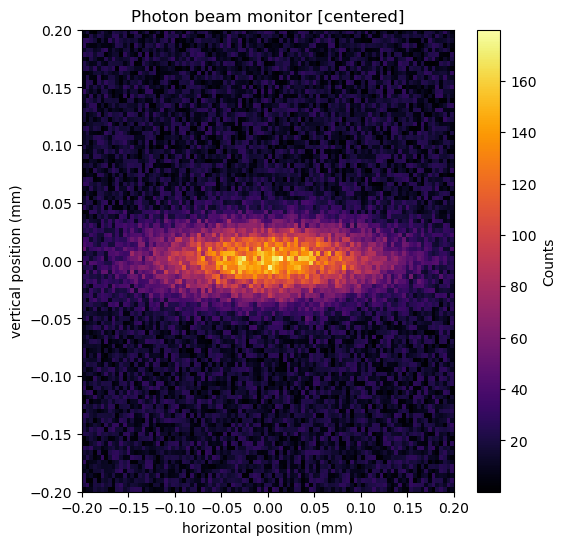

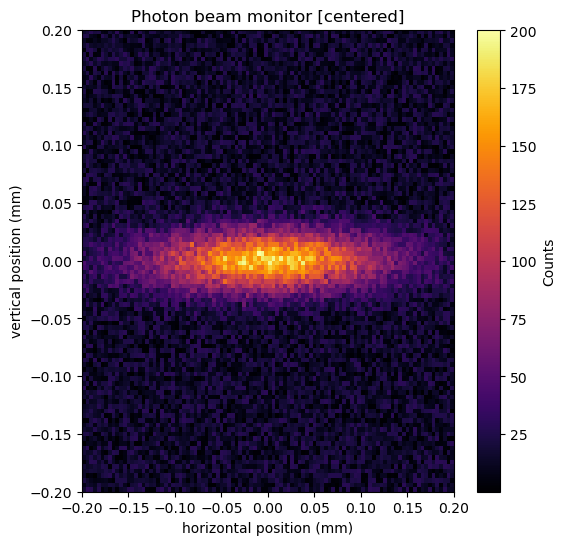

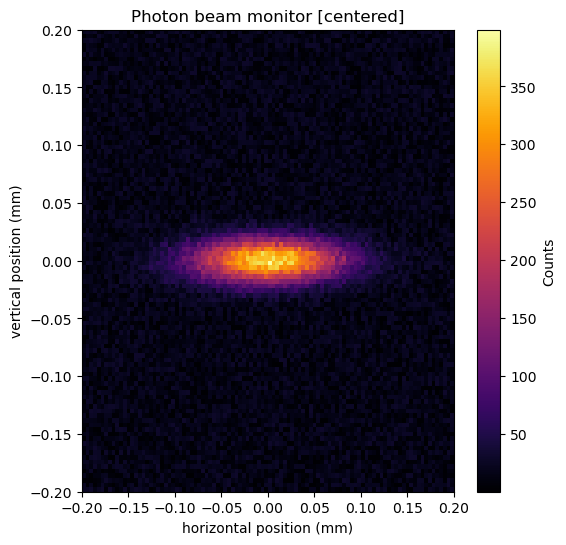

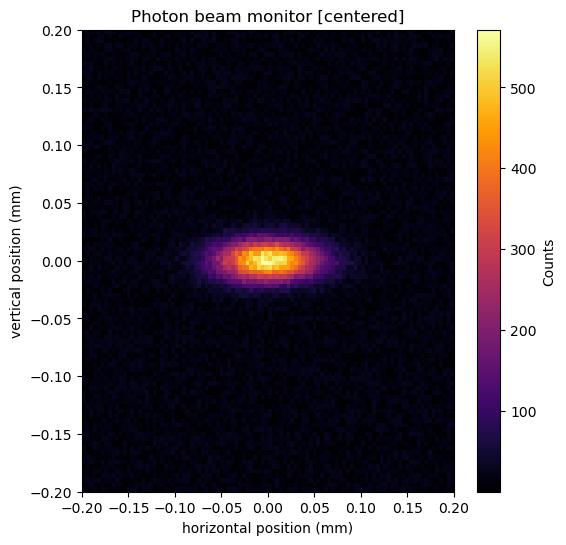

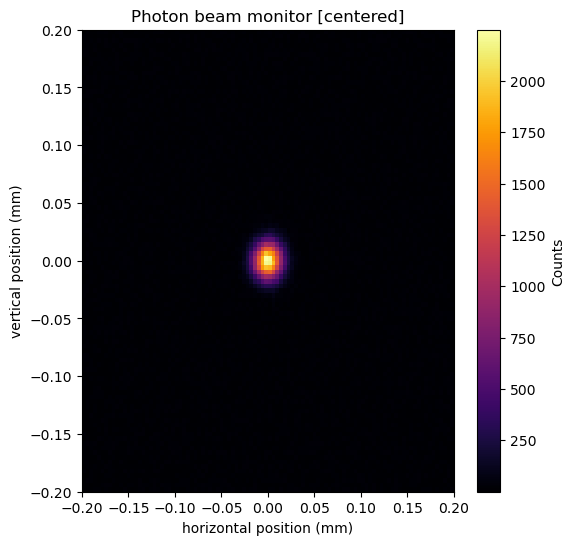

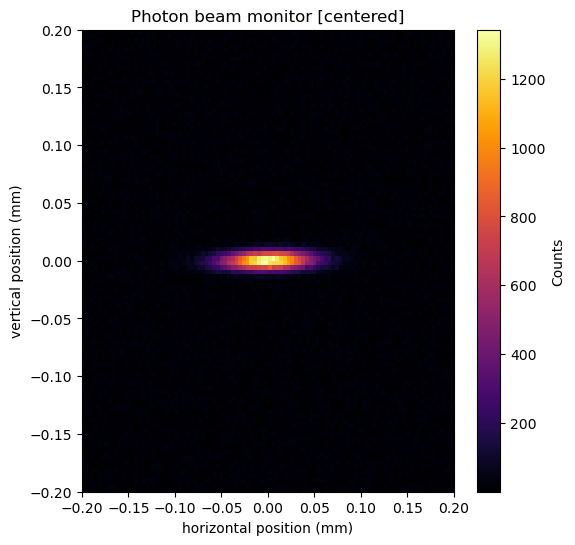

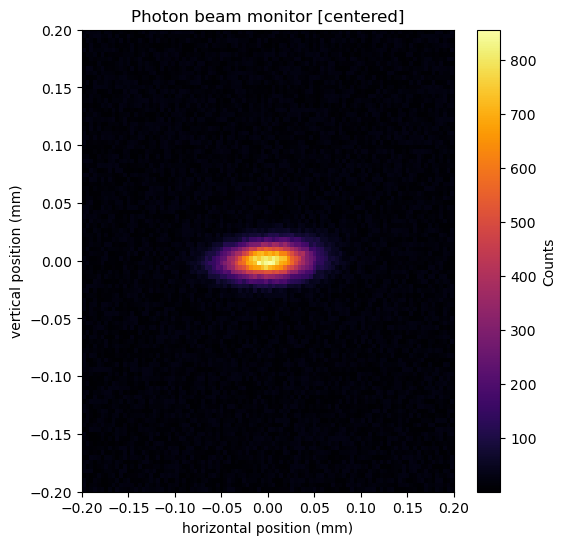

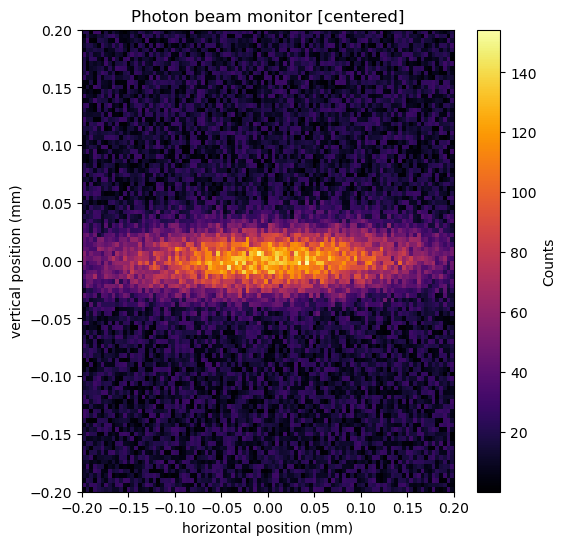

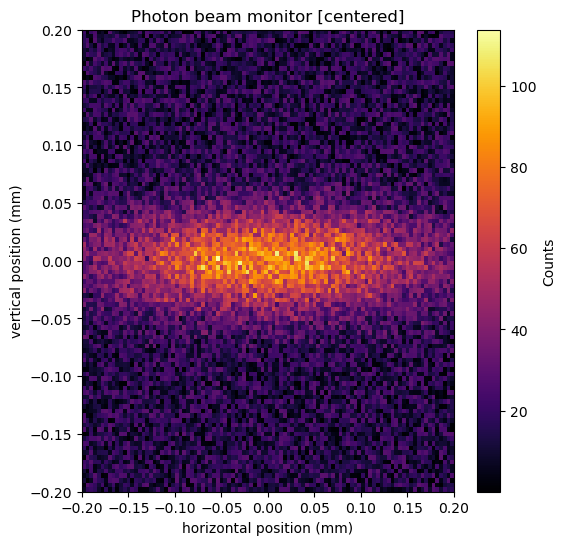

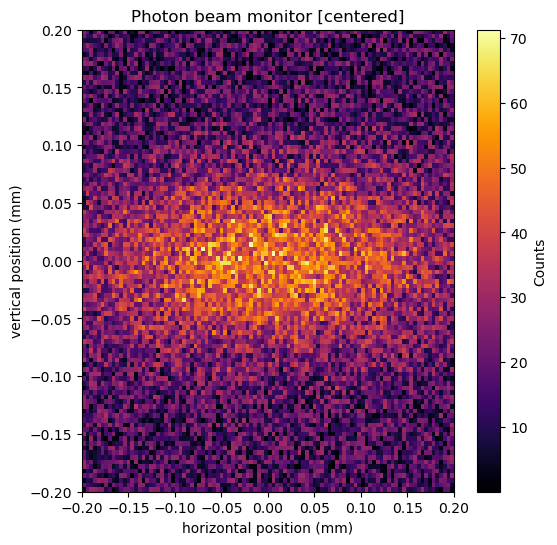

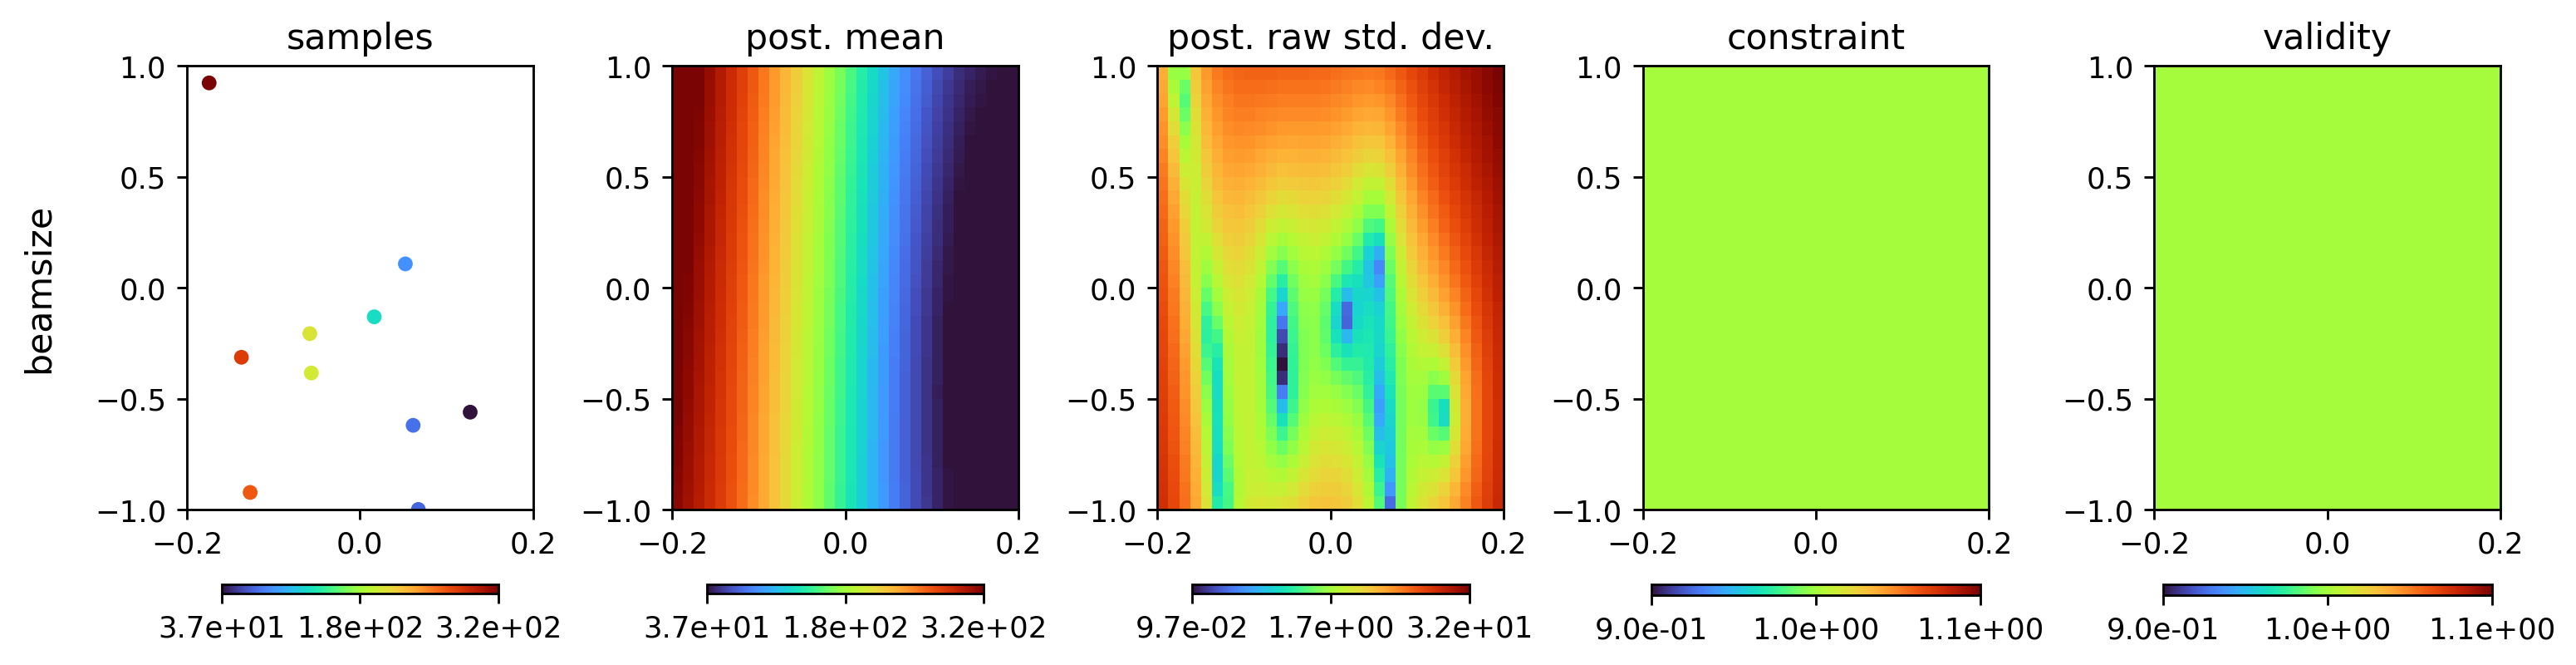

In [10]:
RE(agent.learn("random", n=10))
agent.plot_objectives()

To decide which points to sample, the agent needs an acquisition function. The available acquisition function are here:

In [19]:
# agent.all_acq_funcs
print(agent.db.get_config())
agent.all_acqfs #new

None


,identifier,type,multitask_only,description
name,,,,
expected_improvement,ei,analytic,False,"The expected value of max(f(x) - \nu, 0), wher..."
expected_mean,em,analytic,False,The expected value at each input.
noisy_expected_hypervolume_improvement,nehvi,analytic,True,It's like a big box. How big is the box?
probability_of_improvement,pi,analytic,False,The probability that this input improves on th...
upper_confidence_bound,ucb,analytic,False,"The expected value, plus some multiple of the ..."
lower_bound_max_value_entropy,lbmve,monte_carlo,False,"Max entropy search, basically"
monte_carlo_expected_improvement,qei,monte_carlo,False,"The expected value of max(f(x) - \nu, 0), wher..."
monte_carlo_expected_mean,qem,monte_carlo,False,The expected value at each input.
monte_carlo_noisy_expected_hypervolume_improvement,qnehvi,monte_carlo,True,It's like a big box. How big is the box?


Now we can start to learn intelligently. Using the shorthand acquisition functions shown above, we can see the output of a few different ones:

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


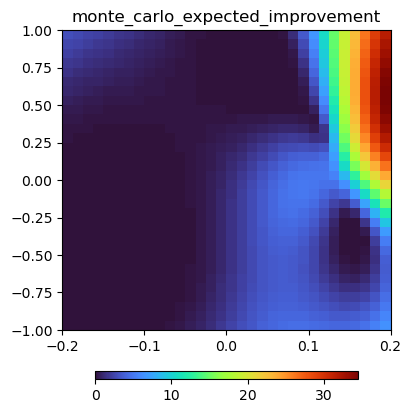

In [13]:
#agent.plot_acquisition(acq_func="qei")
agent.plot_acquisition(acqf="qei") # new

To decide where to go, the agent will find the inputs that maximize a given acquisition function:

In [14]:
agent.ask("qei", n=1)

{'points': {'x_rot': [0.2], 'y_rot': [0.5602232]},
 'acqf_name': 'monte_carlo_expected_improvement',
 'acqf_obj': [35.566286434826274],
 'acqf_kwargs': {'best_f': -27.58350813818481},
 'duration_ms': 281.00000000267755,
 'sequential': True,
 'upsample': 1,
 'read_only_values': tensor([], size=(1, 0))}

We can also ask the agent for multiple points to sample and it will jointly maximize the acquisition function over all sets of inputs, and find the most efficient route between them:

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


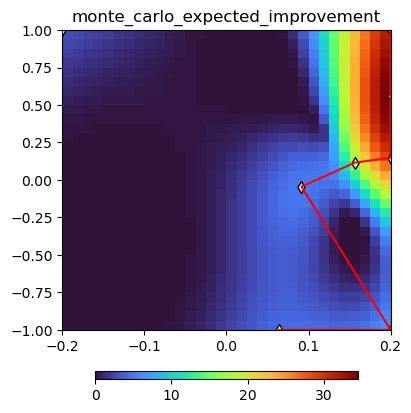

In [15]:
# res = agent.ask("qei", n=8, route=True)
# agent.plot_acquisition(acq_func="qei")
# plt.scatter(*res["points"].T, marker="d", facecolor="w", edgecolor="k")
# plt.plot(
#     *res["points"].T,
#     color="r",
# )
# new
res = agent.ask("qei", n=8, route=True)
agent.plot_acquisition(acqf="qei")
plt.scatter(res["points"]["x_rot"], res["points"]["y_rot"], marker="d", facecolor="w", edgecolor="k")
plt.plot(res["points"]["x_rot"], res["points"]["y_rot"], color="r")
plt.show()

All of this is automated inside the ``learn`` method, which will find a point (or points) to sample, sample them, and retrain the model and its hyperparameters with the new data. To do 4 learning iterations of 8 points each, we can run

In [62]:
RE(agent.learn("qei", n=4, iterations=8))

2025-09-10 16:07:39.372 INFO: Executing plan <generator object Agent.learn at 0x0000012B9CB92B90>
2025-09-10 16:07:39.375 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x0000012B97F84730> from 'idle' -> 'running'




Transient Scan ID: 24     Time: 2025-09-10 16:07:40
Persistent Unique Scan ID: 'f0b9705d-9617-4148-b819-11a31f8a78ce'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      x_rot |      y_rot |
+-----------+------------+------------+------------+
|         1 | 16:07:40.4 |      0.128 |     -0.468 |
|         2 | 16:07:40.4 |      0.120 |     -0.063 |
|         3 | 16:07:40.4 |      0.121 |     -0.022 |
|         4 | 16:07:40.5 |      0.123 |      0.011 |
+-----------+------------+------------+------------+
generator list_scan ['f0b9705d'] (scan num: 24)





C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 25     Time: 2025-09-10 16:07:48
Persistent Unique Scan ID: '991eab65-7b67-43f9-9168-b1578c514fab'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      x_rot |      y_rot |
+-----------+------------+------------+------------+
|         1 | 16:07:48.6 |      0.200 |     -1.000 |
|         2 | 16:07:48.6 |      0.200 |      1.000 |
|         3 | 16:07:48.6 |      0.063 |      1.000 |
|         4 | 16:07:48.6 |     -0.200 |      1.000 |
+-----------+------------+------------+------------+
generator list_scan ['991eab65'] (scan num: 25)





C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

...



Transient Scan ID: 30     Time: 2025-09-10 16:08:44
Persistent Unique Scan ID: '23620e16-9ec4-4d88-9481-3b0dd65ba888'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      x_rot |      y_rot |
+-----------+------------+------------+------------+
|         1 | 16:08:44.6 |      0.019 |      0.627 |
|         2 | 16:08:44.6 |     -0.186 |      0.607 |
|         3 | 16:08:44.7 |     -0.084 |      0.414 |
|         4 | 16:08:44.7 |     -0.097 |     -0.196 |
+-----------+------------+------------+------------+
generator list_scan ['23620e16'] (scan num: 30)





C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 31     Time: 2025-09-10 16:08:52
Persistent Unique Scan ID: '1a6e0b4b-c1b0-4c28-89ab-6a378cf4fde9'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      x_rot |      y_rot |
+-----------+------------+------------+------------+
|         1 | 16:08:52.9 |     -0.023 |      0.164 |
|         2 | 16:08:53.0 |     -0.041 |      0.463 |
|         3 | 16:08:53.0 |     -0.018 |      0.554 |
|         4 | 16:08:53.0 |      0.164 |      0.899 |
+-----------+------------+------------+------------+
generator list_scan ['1a6e0b4b'] (scan num: 31)





C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

('f0b9705d-9617-4148-b819-11a31f8a78ce',
 '991eab65-7b67-43f9-9168-b1578c514fab',
 'ee100874-e1ab-417b-8159-04e13700910a',
 '59326281-c5d7-4d14-a2bf-55ae3fb729ec',
 '97f003c1-2ff8-4387-8d34-ceac7807e4c7',
 '31b5daf0-b7cf-459f-8650-064de225d39b',
 '23620e16-9ec4-4d88-9481-3b0dd65ba888',
 '1a6e0b4b-c1b0-4c28-89ab-6a378cf4fde9')

Our agent has found all the global minima of the defined function toroid using Bayesian optimization, and we can ask it for the best point: 

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


x_rot                               0.121173
y_rot                              -0.004113
beamsize                           23.673593
time           2025-09-10 23:08:26.749273539
acqf        monte_carlo_expected_improvement
Name: 18, dtype: object


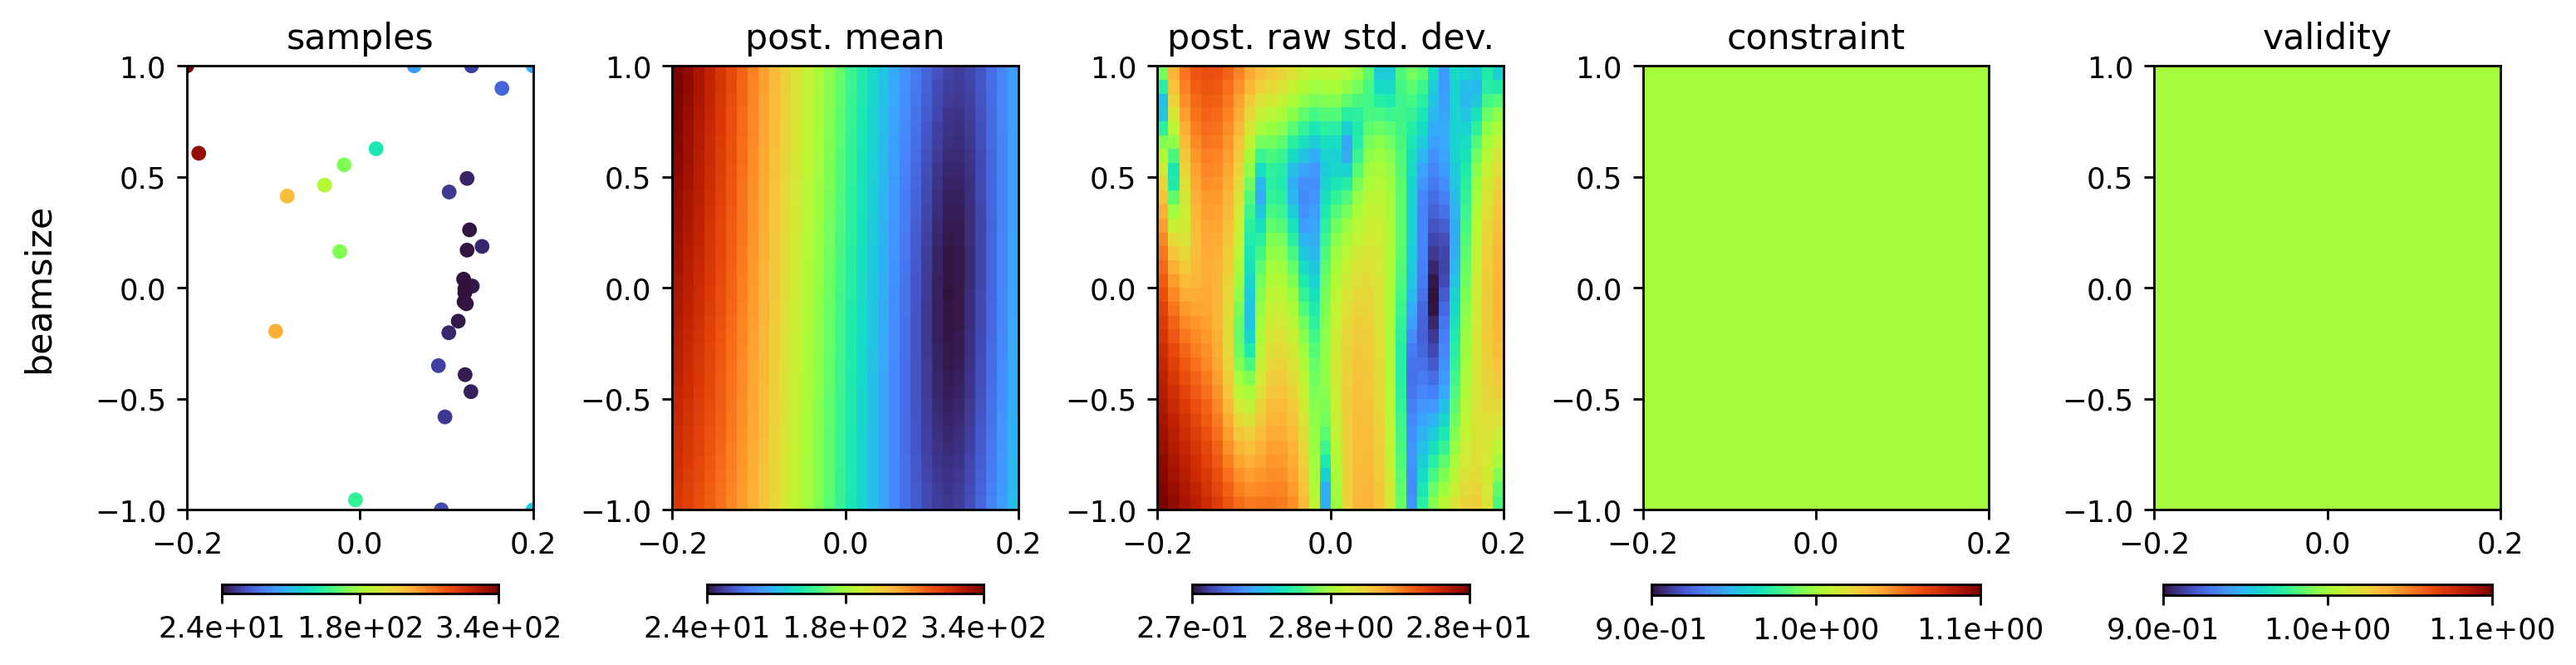

In [63]:
agent.plot_objectives()
print(agent.best)